In [1]:
%load_ext autoreload
%autoreload 2
%cd /opt/tiger/samantha

/opt/tiger/samantha


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# from samantha.utils.hdfs_tools import hdfs_get
# from recipes.mi1.models.music_sft import MI1_MusicClassificationMusicSFT

# model_mcc30k_genre = MI1_MusicClassificationMusicSFT.load_from_checkpoint("/mnt/bn/janne-research-xl/models/m1/m1_music_sft_v0_umm_lr5.0e-5_precision32_1layer_mcc30k_genre_zh_step=0030000.ckpt")
# model_mcc30k_genre = model_mcc30k_genre.to("cuda")
# print("Vocab:", model_mcc30k_genre.tag_tokenizer.vocab)

# model_vocal_gender = MI1_MusicClassificationMusicSFT.load_from_checkpoint("/mnt/bn/janne-research-xl/models/m1/m1_music_sft_vocal_v0_umm_1layer_classification_vocalgender_step=0030000.ckpt")
# model_vocal_gender = model_vocal_gender.to("cuda")

# print("Vocab:", model_vocal_gender.tag_tokenizer.vocab)


# model_mcc30k_mood = MI1_MusicClassificationMusicSFT.load_from_checkpoint("/mnt/bn/janne-research-xl/models/m1/m1_music_sft_v0_umm_lr5.0e-5_precision32_1layer_mood_zh_step=0030000.ckpt")
# model_mcc30k_mood = model_mcc30k_mood.to("cuda")

# print("Mood:", model_mcc30k_mood.tag_tokenizer.vocab)

# model_mcc30k_scene = MI1_MusicClassificationMusicSFT.load_from_checkpoint("/mnt/bn/janne-research-xl/models/m1/m1_music_sft_v0_umm_lr5.0e-5_precision32_1layer_scene_zh_step=0030000.ckpt")
# model_mcc30k_scene = model_mcc30k_scene.to("cuda")

# print("Scene:", model_mcc30k_mood.tag_tokenizer.vocab)


## Statistics

In [59]:
import pandas as pd
import json
from samantha.utils.hdfs_helper import hdfs_ls
from tqdm import tqdm
from glob import glob


def get_index_df(index_uri):
    if index_uri.startswith("hdfs://"):
        index_files = hdfs_ls(index_uri)
    else:
        index_files = glob(index_uri)
    df = pd.concat([pd.read_parquet(f) for f in tqdm(index_files)])
    return pd.json_normalize(df["meta"].apply(json.loads))

In [60]:
df = get_index_df("hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_sft-instrumental_Smcc_Mnonvocal_N5.6k/index_1/*.parquet")
df2 = get_index_df("hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_Ssstk-pond5_Mnonvocal_T44k_N1608k/index_21/part*")

df2["genre_1"] = df2["xbs_label.inspection.genre"].apply(lambda r: ",".join(r))
df2["mood"] = df2["xbs_label.inspection.mood"].apply(lambda r: ",".join(r))
df2["scene"] = df2["xbs_label.inspection.scene"].apply(lambda r: ",".join(r))




df = pd.concat([df, df2])

DATASET_NAME = f"music_sft-instrumental_Smcc_Mnonvocal_N5.6k (V1) AND music_Ssstk-pond5_Mnonvocal_T44k_N1608k (V21)"

2024-01-25 07:05:43,504 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_sft-instrumental_Smcc_Mnonvocal_N5.6k/index_1/*.parquet


100%|██████████| 22/22 [00:00<00:00, 114.47it/s]


2024-01-25 07:05:44,030 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_Ssstk-pond5_Mnonvocal_T44k_N1608k/index_21/part*


100%|██████████| 170/170 [00:01<00:00, 122.87it/s]


In [55]:
df["primary_genre_1"] = df["genre_1"].apply(lambda r: r.split(",")[0])
df["primary_mood"] = df["mood"].apply(lambda r: r.split(",")[0])
df["primary_scene"] = df["scene"].apply(lambda r: r.split(",")[0])

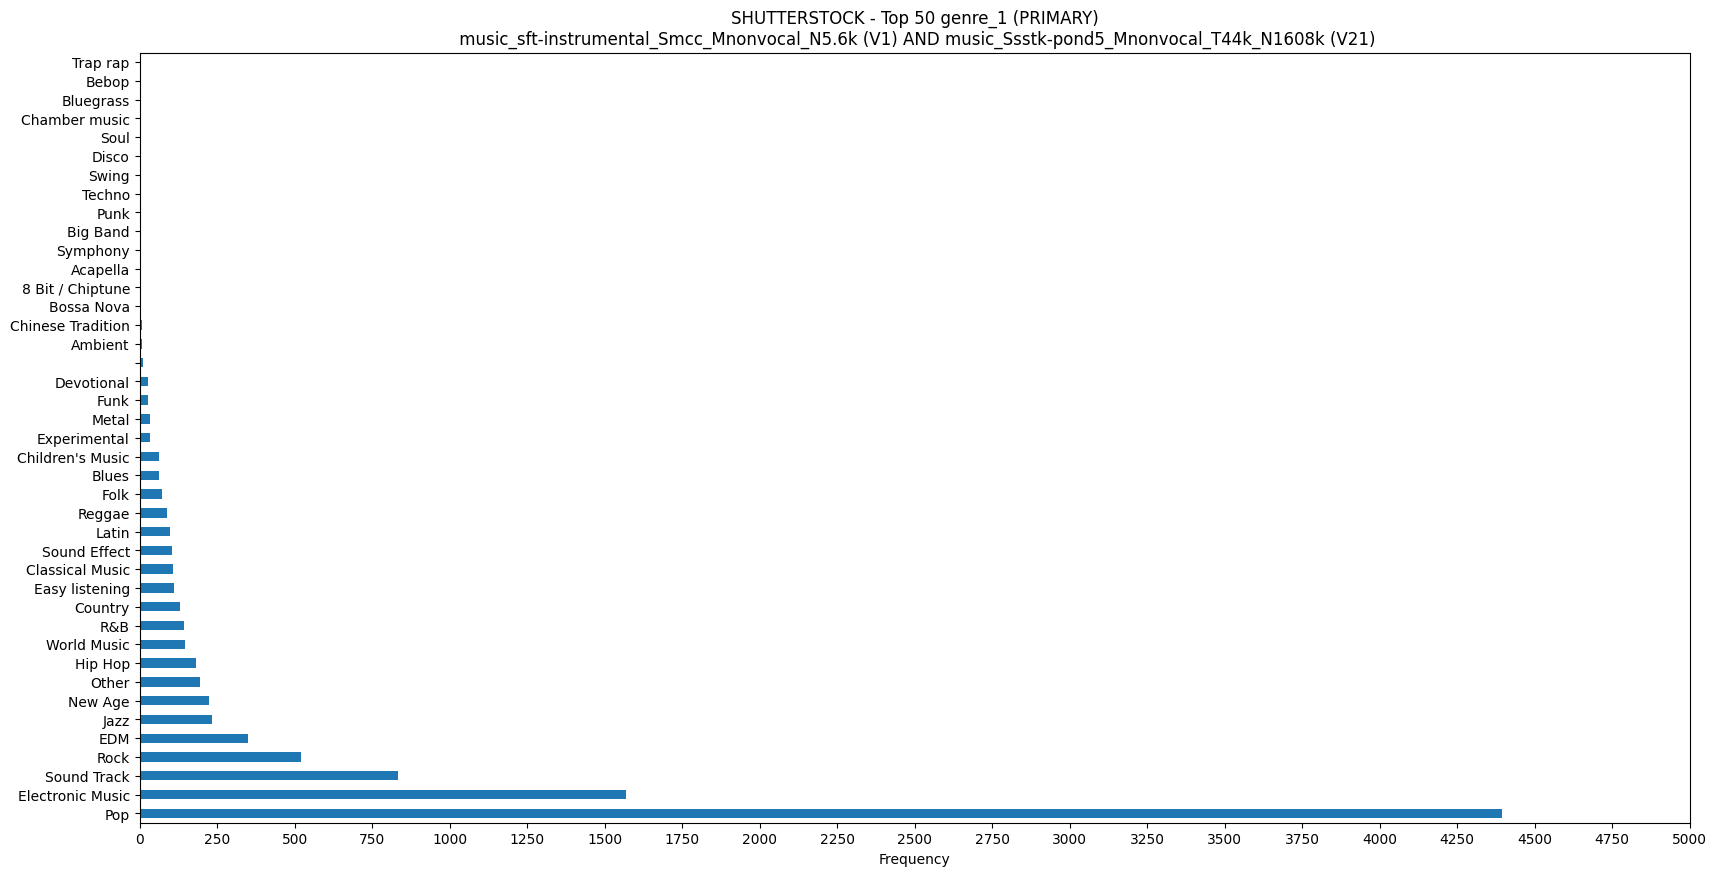

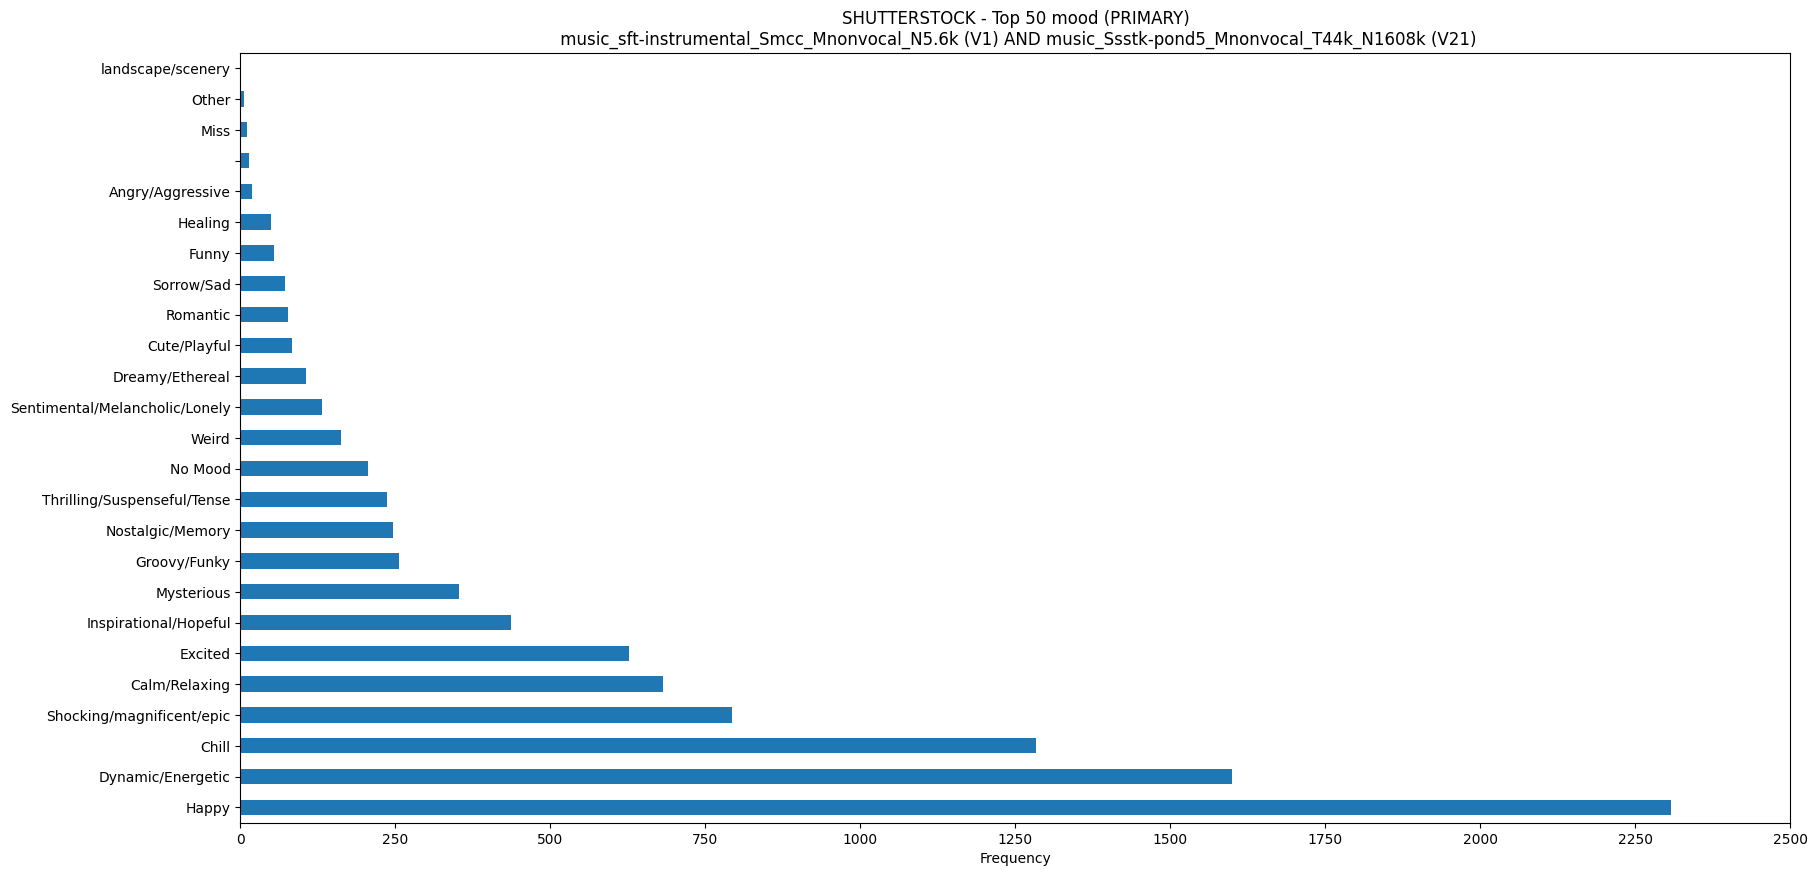

/usr/local/lib/python3.9/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21345 (\N{CJK UNIFIED IDEOGRAPH-5361}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.9/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


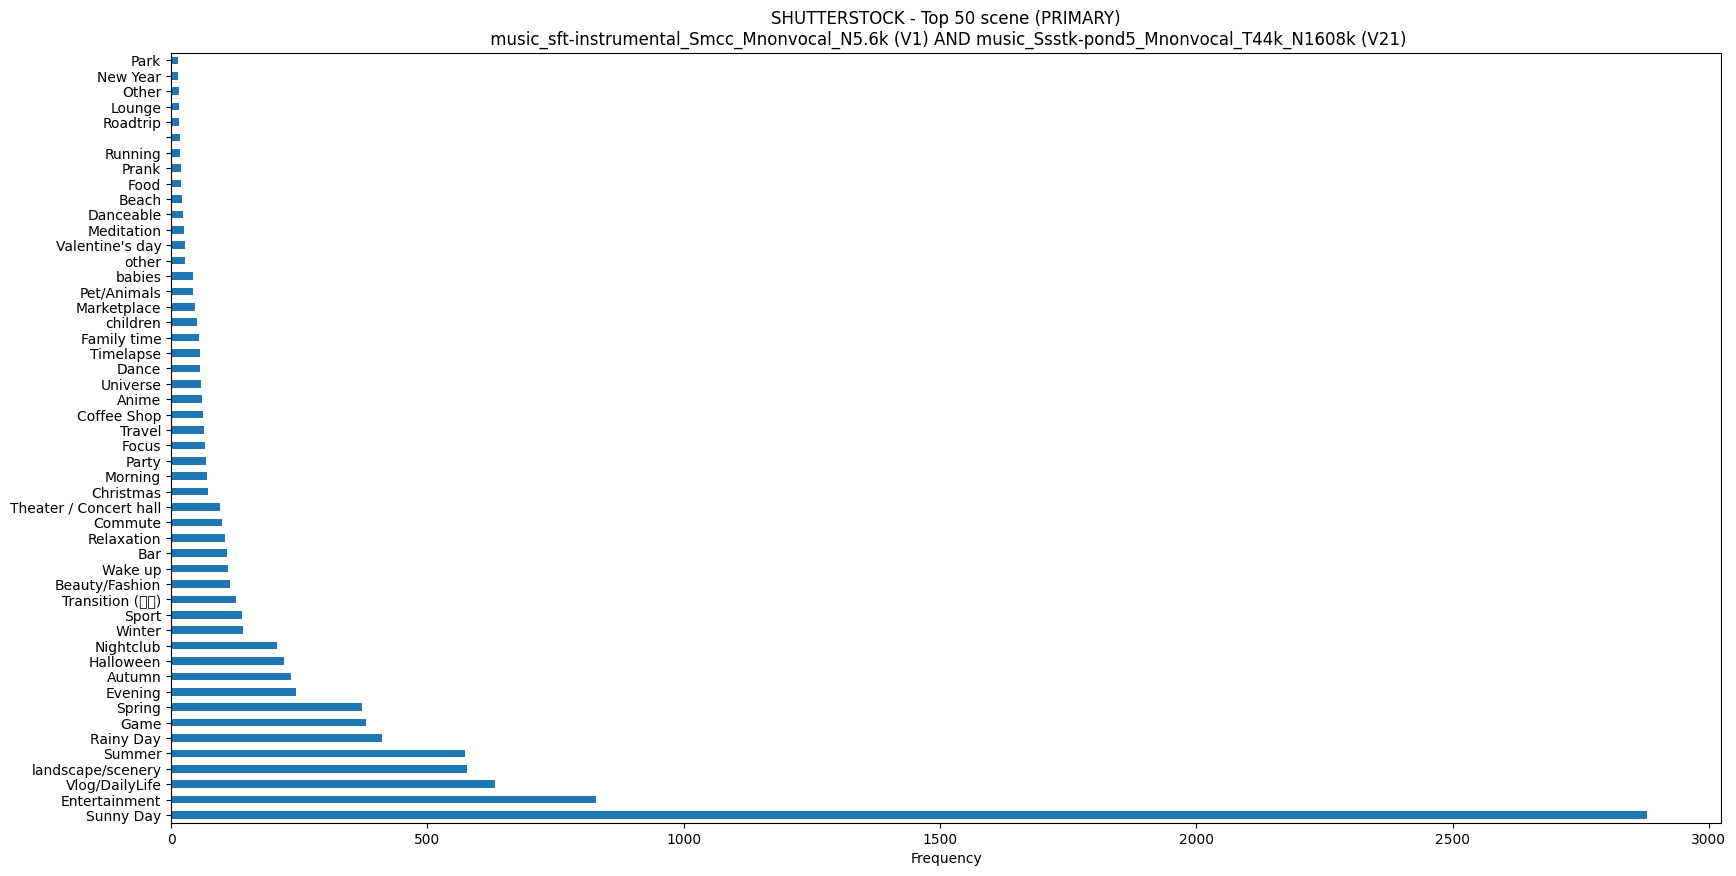

In [56]:
import matplotlib.pyplot as plt
import numpy as np

df["primary_genre_1"].value_counts()[:50].plot.barh(figsize=(20, 10), title=f"SHUTTERSTOCK - Top 50 genre_1 (PRIMARY)\n {DATASET_NAME}")
plt.xticks(np.arange(0, 5250, 250))
plt.xlabel("Frequency")
plt.show()

df["primary_mood"].value_counts()[:50].plot.barh(figsize=(20, 10), title=f"SHUTTERSTOCK - Top 50 mood (PRIMARY)\n {DATASET_NAME}")
plt.xticks(np.arange(0, 2750, 250))
plt.xlabel("Frequency")
plt.show()

df["primary_scene"].value_counts()[:50].plot.barh(figsize=(20, 10), title=f"SHUTTERSTOCK - Top 50 scene (PRIMARY)\n {DATASET_NAME}")
plt.xlabel("Frequency")
plt.show()

## Pre-processed

In [135]:
# df = get_index_df("hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_sft-instrumental_Smcc_Mnonvocal_N5.6k/index_1/*.parquet")
!pip3 install -q ujson
from recipes.mi1.data_enriched.reader import IndexReader

tag_key = "scene"

dfs = []
for fp in glob(f"/mnt/bn/janne-research-xl/data/music_sft/english/shutterstock/{tag_key}/*"):
    try:
        reader = IndexReader(f"{fp}/url2index.txt")
        dfs.append(reader.indexes)    
    except:
        pass
dfs = pd.concat(dfs)

DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
Loaded 1 index urls


100%|██████████| 1/1 [00:00<00:00, 281.04it/s]


Loaded 1 index urls


100%|██████████| 1/1 [00:00<00:00, 161.28it/s]


Loaded 1 index urls


...

100%|██████████| 1/1 [00:00<00:00, 229.05it/s]


Loaded 1 index urls


100%|██████████| 1/1 [00:00<00:00, 685.90it/s]


Loaded 2 index urls


100%|██████████| 2/2 [00:00<00:00, 119.64it/s]


/usr/local/lib/python3.9/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21345 (\N{CJK UNIFIED IDEOGRAPH-5361}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.9/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


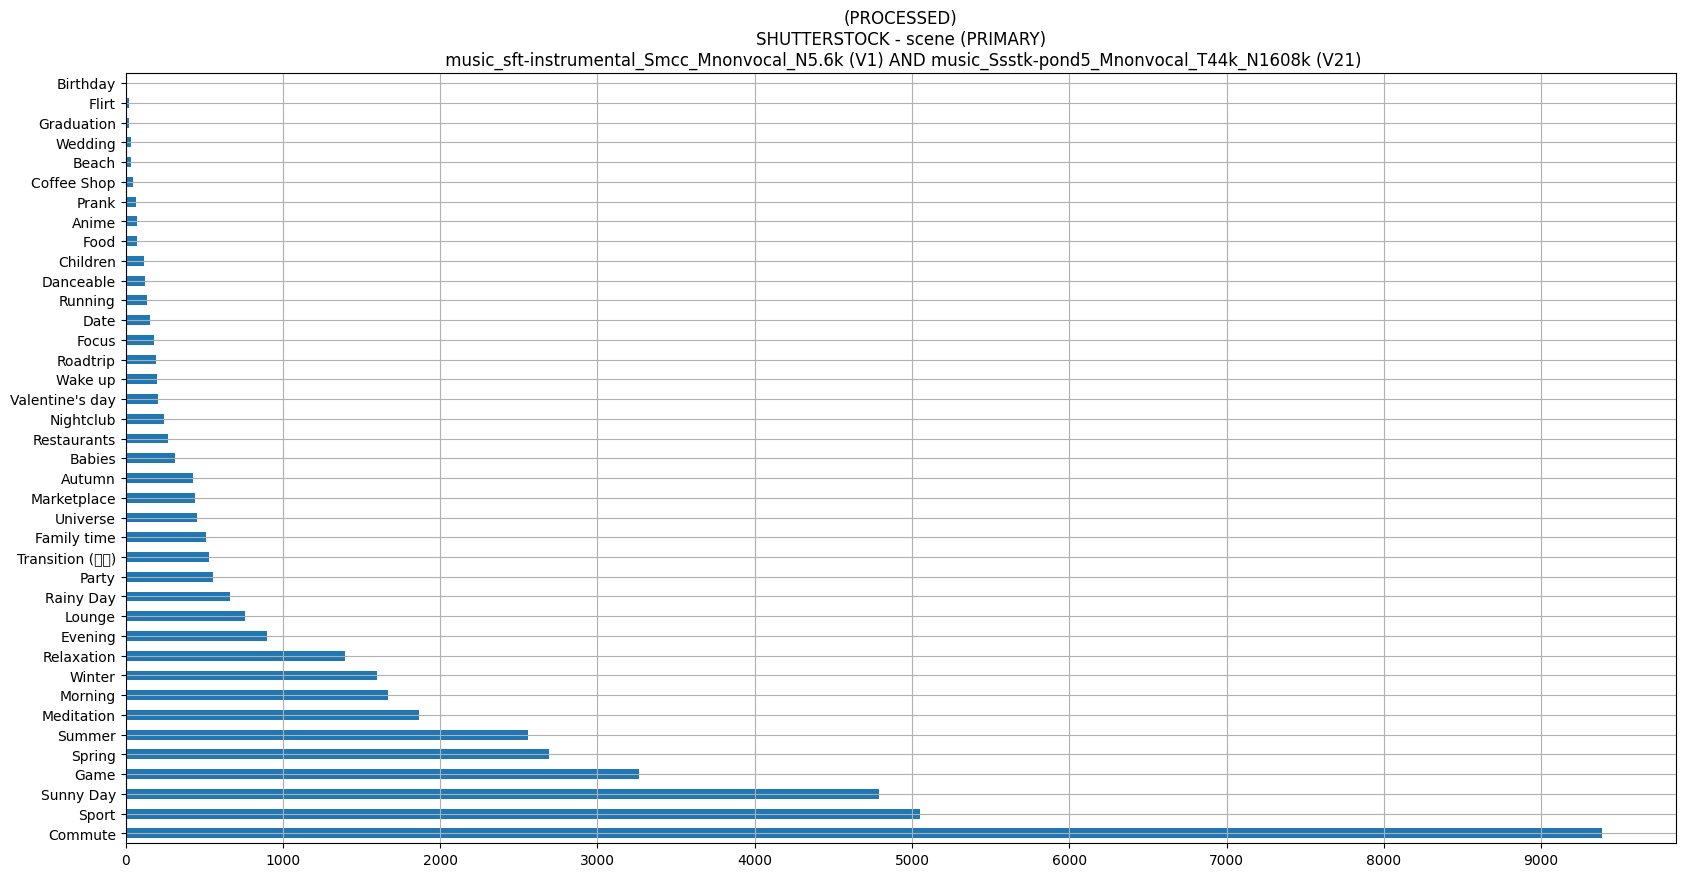

In [136]:
stepsize = 1000
ax = dfs["tag_names"].value_counts().plot.barh(figsize=(20, 10), title=f"(PROCESSED)\nSHUTTERSTOCK - {tag_key} (PRIMARY)\n {DATASET_NAME}")
start, end = ax.get_xlim()
ax.xaxis.set_ticks(np.arange(start, end, stepsize))
plt.grid()
plt.show()

In [17]:
from recipes.datasets.mir.shutterstock import ShutterStockSFTDataModule
from recipes.datasets.mir.taxonomies.music_sft_en import MusicSFTTokenizerGenresEN

datamodule = ShutterStockSFTDataModule(
    tag_key="genre_1",
    sample_rate=24000,
    duration=30,
    batch_size=50,
    shuffle_buffer_size=0,
    resampled=False,
    shardshuffle=False,
    num_workers=8
)
train_loader = datamodule.train_dataloader()

2024-01-24 08:08:54,756 - bytedance.easycycle.bigspeech - INFO - region: Region.I18n
2024-01-24 08:08:54,758 - bytedance.easycycle.bigspeech - INFO - req body: {"id": 118, "trail_id": "4191945"}, headers: {'content-type': 'application/json'}
2024-01-24 08:08:54,849 - bytedance.easycycle.bigspeech - INFO - post https://bigspeech.byteintl.net/platform/api/v3/data/dataset_collection/get_dataset_collection_info, status code: 200, body: {"paths":[{"data":"hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_sft-instrumental_Smcc_Mnonvocal_N5.6k/data//*.parquet","index":"hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_sft-instrumental_Smcc_Mnonvocal_N5.6k/index_1//*.parquet"}]}, headers: {'Date': 'Wed, 24 Jan 2024 00:08:54 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Vary': 'Accept-Encoding', 'X-Tt-Logid': '202401240008530289E88F1790AE87D427', 'server-timing': 'in

parse urls:   0%|          | 0/1 [00:00<?, ?it/s]

2024-01-24 08:08:54,950 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_sft-instrumental_Smcc_Mnonvocal_N5.6k/index_1


parse urls: 100%|██████████| 1/1 [00:00<00:00,  5.65it/s]

2024-01-24 08:08:55,048 - bytedance.easycycle.bigspeech - INFO - region: Region.I18n
2024-01-24 08:08:55,049 - bytedance.easycycle.bigspeech - INFO - req body: {"id": 118, "trail_id": "4191945"}, headers: {'content-type': 'application/json'}


2024-01-24 08:08:55,097 - bytedance.easycycle.bigspeech - INFO - post https://bigspeech.byteintl.net/platform/api/v3/data/dataset_collection/get_dataset_collection_info, status code: 200, body: {"paths":[{"data":"hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_sft-instrumental_Smcc_Mnonvocal_N5.6k/data//*.parquet","index":"hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_sft-instrumental_Smcc_Mnonvocal_N5.6k/index_1//*.parquet"}]}, headers: {'Date': 'Wed, 24 Jan 2024 00:08:55 GMT', 'Content-Type': 'application/json; charset=utf-8', 'Transfer-Encoding': 'chunked', 'Connection': 'keep-alive', 'Vary': 'Accept-Encoding', 'X-Tt-Logid': '20240124000854860E1813B9733E8F85D9', 'server-timing': 'inner; dur=24', 'x-tt-trace-host': '015b3f4f93d54ed6e51e292f03434c52f5af228b7eb06dbc0b4ca2676fd4fa19a3e612b0e861d8a0269473fba09be8afee9f4dda631f85b4ccd6e7bd99578d0cf59bb0d8aad6099d78519695ce41402ce345387cf945b5b4034b81041f86379d4e47a9cc02cbb9f4

parse urls:   0%|          | 0/1 [00:00<?, ?it/s]

2024-01-24 08:08:55,194 - samantha.utils.hdfs_helper - INFO - Listing HDFS directory hdfs://harunava/home/byte_data_seed_us/hdd_va/speech/data_store/BigMusic/music_sft-instrumental_Smcc_Mnonvocal_N5.6k/index_1


parse urls: 100%|██████████| 1/1 [00:00<00:00,  3.15it/s]


In [18]:
batch = next(iter(train_loader))

In [56]:
from recipes.datasets.mir.shutterstock import ShutterStockPreprocessedDataModule
from recipes.datasets.mir.taxonomies.music_sft_en import MusicSFTTokenizerGenresEN

datamodule = ShutterStockPreprocessedDataModule(
    tag_key="mood",
    sample_rate=24000,
    duration=30,
    batch_size=50,
    shuffle_buffer_size=0,
    resampled=False,
    shardshuffle=False,
    num_workers=8
)
train_loader = datamodule.train_dataloader()
batch = next(iter(train_loader))


initializing train datasets...
adding dataset: /mnt/bn/janne-research-xl/data/music_sft/english/shutterstock/mood/Chill/url2index.txt
adding dataset: /mnt/bn/janne-research-xl/data/music_sft/english/shutterstock/mood/angry, aggressive/url2index.txt
adding dataset: /mnt/bn/janne-research-xl/data/music_sft/english/shutterstock/mood/calm, relaxing/url2index.txt
adding dataset: /mnt/bn/janne-research-xl/data/music_sft/english/shutterstock/mood/cute, playful/url2index.txt
adding dataset: /mnt/bn/janne-research-xl/data/music_sft/english/shutterstock/mood/dreamy, ethereal/url2index.txt
adding dataset: /mnt/bn/janne-research-xl/data/music_sft/english/shutterstock/mood/dynamic, energetic/url2index.txt
adding dataset: /mnt/bn/janne-research-xl/data/music_sft/english/shutterstock/mood/excited/url2index.txt
adding dataset: /mnt/bn/janne-research-xl/data/music_sft/english/shutterstock/mood/funny/url2index.txt
adding dataset: /mnt/bn/janne-research-xl/data/music_sft/english/shutterstock/mood/groovy,

In [57]:
batch.tag_ids

tensor([19, 14,  9, 18, 12, 15,  3,  7, 11,  5,  9,  3,  7, 12,  9,  8,  8,  4,
        13, 15,  4, 13,  2, 10,  4, 11, 11, 13, 14,  4, 16, 12,  3,  3,  9, 18,
        11,  9, 15,  7,  5,  0, 14,  6, 10,  9, 17,  0, 19, 17])